# Lab 7 — Image Segmentation and Feature Extraction
**Course:** ARTI407 – Image Processing  
**College of Computer Science and Information Technology**  
**Imam Abdulrahman Bin Faisal University**

This notebook contains:
1. The two examples from the lab manual (Canny Edge Detection, Harris Corner Detection).
2. The assessment task (Otsu's thresholding).



## Setup — Import libraries

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import data   # provides sample images (camera, checkerboard, coins, ...)

# Make plots show inside the notebook
%matplotlib inline

## Task 1 — Canny Edge Detection

An **edge** is where brightness changes sharply. Canny finds edges in 5 steps: Gaussian blur → gradients → non-maximum suppression (thin the edges) → double thresholding → hysteresis (keep weak edges only if they connect to strong ones).

`cv2.Canny(img, T_low, T_high)`:
- `T_low` = lower threshold (weak edges)
- `T_high` = upper threshold (strong edges)
- Rule of thumb: `T_high ≈ 2×T_low` or `3×T_low`.

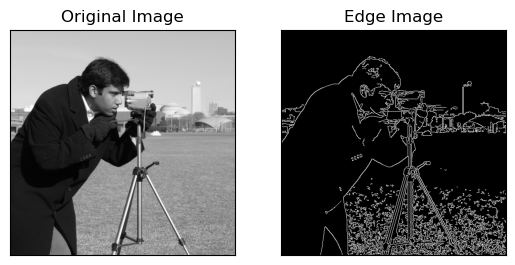

In [2]:
# --- Code from the lab manual ---
img = data.camera()

# canny edge detection
edges = cv2.Canny(img, 100, 200) 
# canny take img, 100: lower threshold, 200: upper threshold
# two threshold to find edges. edges become white, rest become black
# pixel bigger then 200 -> its an edge, convert it to white
# pixel less then 100 -> not an edge, make it black

plt.subplot(121), plt.imshow(img, cmap='gray')
plt.title('Original Image'), plt.xticks([]), plt.yticks([])
plt.subplot(122), plt.imshow(edges, cmap='gray')
plt.title('Edge Image'), plt.xticks([]), plt.yticks([])
plt.show()

## Task 2 — Harris Corner Detection

A **corner** is a point where the image changes in *two* different directions, which makes corners highly distinctive.



- Large positive `R` → corner
- Large negative `R` → edge
- Small `R` → flat region

Parameters: `blockSize` (window size), `ksize` (Sobel kernel size), `k` (sensitivity, typically 0.04–0.06).

> **Note:** OpenCV uses BGR order, so `(0, 0, 255)` is red.

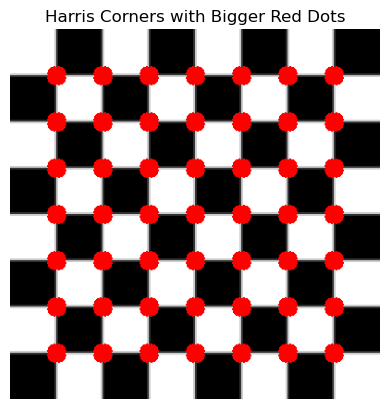

In [3]:
# --- Code from the lab manual ---
board = data.checkerboard() # img
image = cv2.cvtColor(board, cv2.COLOR_GRAY2BGR)# gray to blue green red. optional steps, to show circles in red
image = cv2.resize(image, (400, 400), interpolation=cv2.INTER_NEAREST) # optional, bigger img

# Convert to grayscale
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY) # convert to gray. for math operations
gray = np.float32(gray) # floating: from int to float, for math operations.

# Harris Corner Detection
harris = cv2.cornerHarris(gray, blockSize=2, ksize=3, k=0.04) 
# this will find many corners

# Threshold for detecting strong corners
# showing the strong corners only. one we are sure are corners
threshold = 0.01 * harris.max() # 1% * strongest corners = 10 corners

# compare these strong cornesrs with threshold, this give corners placement
corner_coords = np.argwhere(harris > threshold)


# Draw larger red dots (radius = 7)
for y, x in corner_coords:
    cv2.circle(image, (x, y), radius=7, color=(0, 0, 255), thickness=-1)  # -1 = filled

# Display
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title('Harris Corners with Bigger Red Dots')
plt.axis('off')
plt.show()

## Q1 — Otsu's Thresholding (Assessment Task)
Otsu picks `T` **automatically** by maximizing the between-class variance — assumes the histogram has two peaks (foreground + background).

show the original image, its histogram, and the thresholded image.

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data
from skimage.filters import threshold_otsu

image = data.camera()

# histogram shows pixels , intensity value.
# image is grayscale, intensity values range from 0 (black) to 255 (white).
histogram, bins = np.histogram(image.ravel(), bins=256, range=(0, 256))

# Otsu's method automatically finds the best threshold T.
# It tries different possible threshold values and selects the one that gives the maximum separation between Background pixels and Foreground pixels
threshold = threshold_otsu(image)
print("Otsu Threshold:", threshold)


# Create the thresholded (binary) image
# Pixels greater than the Otsu threshold become WHITE (255).
# Pixels less than or equal to the threshold become BLACK (0).
# This converts the original grayscale image into a binary image.
thresholded_image = image > threshold


Otsu Threshold: 102


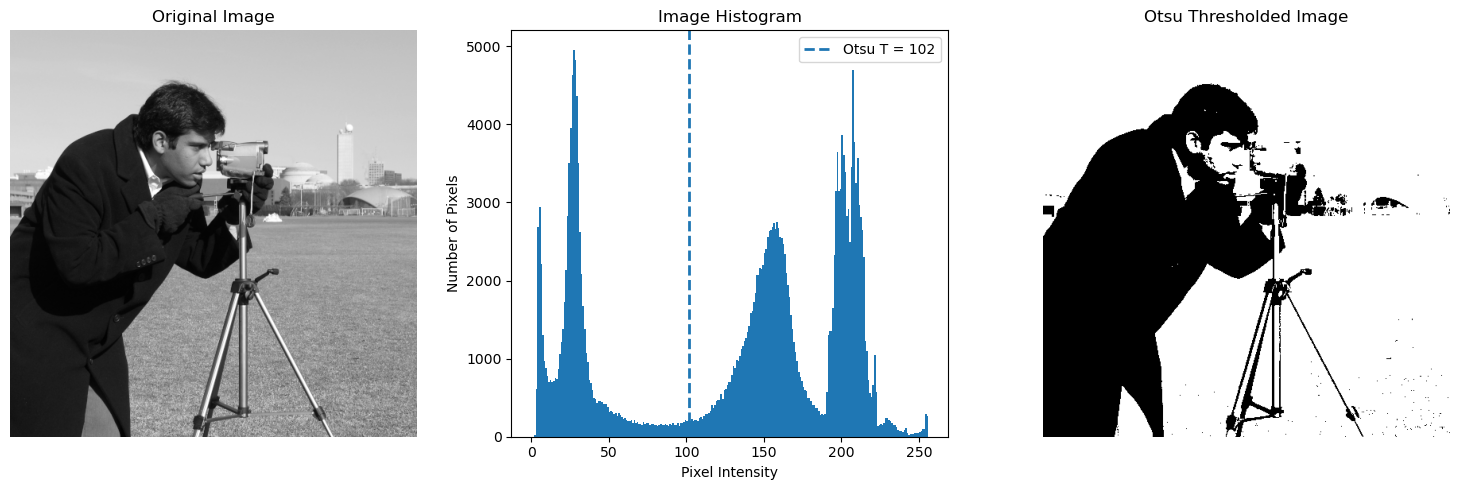

In [5]:
# Display 
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.imshow(image, cmap='gray')
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.hist(image.ravel(), bins=256, range=(0, 256))
plt.axvline(threshold, linestyle='--', linewidth=2,
            label=f"Otsu T = {threshold}")
plt.title("Image Histogram")
plt.xlabel("Pixel Intensity")
plt.ylabel("Number of Pixels")
# display the threshold value in the legend.
plt.legend()

plt.subplot(1, 3, 3)
plt.imshow(thresholded_image, cmap='gray')
plt.title("Otsu Thresholded Image")
plt.axis("off")


plt.tight_layout()
plt.show()

---
## Summary table

| Technique | Category | What it finds | OpenCV function |
|---|---|---|---|
| Canny | Edge detection | Thin connected edges | `cv2.Canny` |
| Sobel | Edge detection | Gradient magnitude (thick) | `cv2.Sobel` |
| Laplacian | Edge detection | Zero-crossings (2nd deriv) | `cv2.Laplacian` |
| Harris | Feature extraction | Corners | `cv2.cornerHarris` |
| Shi-Tomasi | Feature extraction | Corners (improved) | `cv2.goodFeaturesToTrack` |
| Simple threshold | Segmentation | Fixed-`T` binary mask | `cv2.threshold` |
| Otsu | Segmentation | Auto bimodal threshold | `cv2.threshold` + `THRESH_OTSU` |
| Adaptive threshold | Segmentation | Local-`T` binary mask | `cv2.adaptiveThreshold` |

**End of notebook.**